# ATAC-informed prediction of short-range cis chromatin contacts in GM12878

## Overview

This analysis tests whether chromatin accessibility provides predictive information about short-range Hi-C contact strength beyond genomic distance alone. It integrates matched GM12878 ATAC-seq and Hi-C data from ENCODE at 100-kb resolution.

The primary model is trained on chromosomes 16–19, selected using chromosome 20 and evaluated once on the long arm of chromosome 21. A nested leave-one-chromosome-out analysis then assesses generalisation across all six chromosomes without using each test chromosome for model selection.

### Principal findings

- On the independent chromosome-21 test set, adding ATAC-derived features to genomic distance reduced MSE by **29.57%** and MAE by **29.73%**.
- The combined model achieved Pearson \(r=0.821\), Spearman \(\rho=0.858\) and \(R^2=0.672\).
- Nested chromosome-level validation improved MSE on **6 of 6 chromosomes**, with a median reduction of **45.80%**.
- Distance was the dominant individual predictor, but the distance-plus-ATAC model outperformed distance-only and ATAC-only models.

These findings support a predictive association between accessibility and local contact strength. They do not establish causality or imply that ATAC-seq can reconstruct complete Hi-C maps.

## 1. Environment and analysis configuration

The workflow uses fixed random seeds and explicitly records the biological and modelling parameters. Hi-C contacts are balanced using VC_SQRT; raw unnormalised counts are not used in the validated analysis.

In [1]:
from pathlib import Path
import json
import os
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import pearsonr, spearmanr
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

RESOLUTION_BP = 100_000
MAXIMUM_DISTANCE_BINS = 15
MAXIMUM_SEPARATION_BP = RESOLUTION_BP * MAXIMUM_DISTANCE_BINS
CHROMOSOMES = ["chr16", "chr17", "chr18", "chr19", "chr20", "chr21"]
TRAINING_CHROMOSOMES = ["chr16", "chr17", "chr18", "chr19"]
VALIDATION_CHROMOSOME = "chr20"
TEST_CHROMOSOME = "chr21"
CHR21_MINIMUM_BIN = 130  # 13 Mb; excludes the poorly mapped short arm

PROJECT_ROOT = Path("/content") if Path("/content").exists() else Path.cwd()
DATA_PATH = PROJECT_ROOT / "GM12878_VC_SQRT_multichromosome_data.npz"
RESULTS_DIR = PROJECT_ROOT / "validated_results"
RESULTS_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed dataset:", DATA_PATH)

Project root: /workspace/scratch/c48aa57ced8f/deliverables
Processed dataset: /workspace/scratch/c48aa57ced8f/deliverables/GM12878_VC_SQRT_multichromosome_data.npz


## 2. Data acquisition and preprocessing

### Data sources

| Assay | ENCODE accession | Cell line | Genome | Processing used here |
|---|---|---|---|---|
| Hi-C | `ENCFF916GWS` | GM12878 | hg38 | Observed contacts, VC_SQRT balanced, 100-kb bins |
| ATAC-seq | `ENCFF667MDI` | GM12878 | hg38 | Mean bigWig signal in matched 100-kb bins |

The cell below downloads and processes the source data only when the processed `.npz` file is absent. In Colab this requires downloading the approximately 1.4-GB ATAC-seq bigWig. The processed dataset is substantially smaller and can be reused on subsequent runs.

In [2]:
if not DATA_PATH.exists():
    import subprocess
    import urllib.request

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "hic-straw", "pyBigWig"],
        check=True,
    )

    import hicstraw
    import pyBigWig

    hic_url = (
        "https://www.encodeproject.org/files/ENCFF916GWS/"
        "@@download/ENCFF916GWS.hic"
    )
    atac_url = (
        "https://www.encodeproject.org/files/ENCFF667MDI/"
        "@@download/ENCFF667MDI.bigWig"
    )
    atac_path = PROJECT_ROOT / "ENCFF667MDI.bigWig"

    if not atac_path.exists():
        print("Downloading GM12878 ATAC-seq bigWig...")
        urllib.request.urlretrieve(atac_url, atac_path)

    hic = hicstraw.HiCFile(hic_url)
    chromosome_lengths = {
        chromosome.name: chromosome.length
        for chromosome in hic.getChromosomes()
    }

    atac_file = pyBigWig.open(str(atac_path))
    processed = {}

    for chromosome in CHROMOSOMES:
        length = chromosome_lengths[chromosome]
        print(f"Processing {chromosome}...")

        hic_data = hic.getMatrixZoomData(
            chromosome,
            chromosome,
            "observed",
            "VC_SQRT",
            "BP",
            RESOLUTION_BP,
        )
        hic_matrix = np.asarray(
            hic_data.getRecordsAsMatrix(0, length, 0, length),
            dtype=np.float32,
        )
        hic_matrix = np.nan_to_num(
            hic_matrix,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )

        atac_values = atac_file.stats(
            chromosome,
            0,
            length,
            nBins=hic_matrix.shape[0],
            type="mean",
        )
        atac_values = np.asarray(
            [0.0 if value is None else value for value in atac_values],
            dtype=np.float32,
        )
        atac_values = np.nan_to_num(atac_values)

        processed[f"{chromosome}_ATAC"] = atac_values
        processed[f"{chromosome}_HiC"] = hic_matrix

    atac_file.close()
    np.savez_compressed(DATA_PATH, **processed)
    print("Processed dataset saved:", DATA_PATH)
else:
    print("Using existing processed dataset:", DATA_PATH)

Using existing processed dataset: /workspace/scratch/c48aa57ced8f/deliverables/GM12878_VC_SQRT_multichromosome_data.npz


### Quality control

The checks below verify matched dimensions, finite non-negative values and symmetric Hi-C matrices. They also report chromosome-specific matrix coverage. Chromosome 21 has lower whole-chromosome coverage because it is acrocentric; its short arm is excluded from modelling.

In [3]:
data = np.load(DATA_PATH, allow_pickle=False)
qc_rows = []

for chromosome in CHROMOSOMES:
    atac = data[f"{chromosome}_ATAC"]
    hic = data[f"{chromosome}_HiC"]

    assert len(atac) == hic.shape[0]
    assert hic.shape[0] == hic.shape[1]
    assert np.isfinite(atac).all() and np.isfinite(hic).all()
    assert (atac >= 0).all() and (hic >= 0).all()

    symmetry_error = float(np.max(np.abs(hic - hic.T)))
    assert symmetry_error < 1e-5

    qc_rows.append({
        "chromosome": chromosome,
        "bins": len(atac),
        "nonzero_HiC_percent": float(np.mean(hic > 0) * 100),
        "symmetry_error": symmetry_error,
    })

qc_table = pd.DataFrame(qc_rows)
qc_table

,chromosome,bins,nonzero_HiC_percent,symmetry_error
0,chr16,904,65.628916,0.0
1,chr17,833,80.390524,0.0
2,chr18,804,85.286410,0.0
3,chr19,587,84.536624,0.0
4,chr20,645,88.656211,0.0
5,chr21,468,52.809738,0.0


## 3. Pairwise feature construction

The unit of analysis is a cis pair of 100-kb genomic bins separated by 100 kb–1.5 Mb. For each pair, the target is \(\log(1+\text{VC\_SQRT Hi-C contact})\).

Features are:

1. genomic separation in 100-kb bins;
2. lower anchor accessibility;
3. higher anchor accessibility;
4. mean anchor accessibility;
5. absolute accessibility difference; and
6. product of anchor accessibilities.

ATAC values are first transformed with \(\log(1+x)\). Pairs are retained only when both bins have measurable chromosome-wide Hi-C coverage. All transformations are deterministic and use no target information from held-out chromosomes.

In [4]:
def create_pairwise_dataset(chromosomes, chromosome_minimum_bins=None):
    if chromosome_minimum_bins is None:
        chromosome_minimum_bins = {}

    full_features = []
    distance_features = []
    targets = []
    metadata = []

    for chromosome in chromosomes:
        atac = np.asarray(data[f"{chromosome}_ATAC"], dtype=float)
        hic = np.asarray(data[f"{chromosome}_HiC"], dtype=float)
        atac = np.log1p(np.clip(atac, 0, None))
        hic_coverage = np.sum(hic, axis=1) > 0
        minimum_bin = chromosome_minimum_bins.get(chromosome, 0)

        for distance in range(1, MAXIMUM_DISTANCE_BINS + 1):
            bin_a = np.arange(minimum_bin, len(atac) - distance)
            bin_b = bin_a + distance
            valid = hic_coverage[bin_a] & hic_coverage[bin_b]
            bin_a = bin_a[valid]
            bin_b = bin_b[valid]

            accessibility_a = atac[bin_a]
            accessibility_b = atac[bin_b]

            pair_features = np.column_stack([
                np.full(len(bin_a), distance),
                np.minimum(accessibility_a, accessibility_b),
                np.maximum(accessibility_a, accessibility_b),
                (accessibility_a + accessibility_b) / 2,
                np.abs(accessibility_a - accessibility_b),
                accessibility_a * accessibility_b,
            ])

            full_features.append(pair_features)
            distance_features.append(np.full((len(bin_a), 1), distance))
            targets.append(np.log1p(hic[bin_a, bin_b]))
            metadata.extend([
                (chromosome, int(a), int(b), distance)
                for a, b in zip(bin_a, bin_b)
            ])

    return (
        np.vstack(full_features).astype(np.float32),
        np.vstack(distance_features).astype(np.float32),
        np.concatenate(targets).astype(np.float32),
        metadata,
    )


X_train, D_train, y_train, train_pairs = create_pairwise_dataset(
    TRAINING_CHROMOSOMES
)
X_validation, D_validation, y_validation, validation_pairs = (
    create_pairwise_dataset([VALIDATION_CHROMOSOME])
)
X_test, D_test, y_test, test_pairs = create_pairwise_dataset(
    [TEST_CHROMOSOME],
    chromosome_minimum_bins={TEST_CHROMOSOME: CHR21_MINIMUM_BIN},
)

dataset_summary = pd.DataFrame([
    {
        "partition": "Training",
        "chromosomes": ", ".join(TRAINING_CHROMOSOMES),
        "pairs": len(y_train),
        "zero_contact_percent": float(np.mean(y_train == 0) * 100),
    },
    {
        "partition": "Validation",
        "chromosomes": VALIDATION_CHROMOSOME,
        "pairs": len(y_validation),
        "zero_contact_percent": float(np.mean(y_validation == 0) * 100),
    },
    {
        "partition": "Independent test",
        "chromosomes": f"{TEST_CHROMOSOME} long arm",
        "pairs": len(y_test),
        "zero_contact_percent": float(np.mean(y_test == 0) * 100),
    },
])
dataset_summary

,partition,chromosomes,pairs,zero_contact_percent
0,Training,"chr16, chr17, chr18, chr19",44427,4.526527
1,Validation,chr20,9540,3.962264
2,Independent test,chr21 long arm,4935,0.790274


## 4. Primary train–validation–test analysis

A distance-only baseline predicts the mean training-set contact at each genomic separation. The main model is a histogram gradient-boosting regressor using distance and ATAC features. Five restrained hyperparameter combinations are compared using chromosome 20 only. Chromosome 21 remains untouched until the final evaluation.

In [5]:
def fit_distance_baseline(distance_features, targets):
    return {
        distance: float(targets[distance_features[:, 0] == distance].mean())
        for distance in range(1, MAXIMUM_DISTANCE_BINS + 1)
    }


def predict_distance_baseline(distance_features, distance_means):
    return np.asarray([
        distance_means[int(distance)]
        for distance in distance_features[:, 0]
    ])


CANDIDATE_SETTINGS = [
    (7, 0.1),
    (15, 0.1),
    (15, 1.0),
    (31, 1.0),
    (31, 10.0),
]

distance_means = fit_distance_baseline(D_train, y_train)
validation_distance_prediction = predict_distance_baseline(
    D_validation, distance_means
)
test_distance_prediction = predict_distance_baseline(D_test, distance_means)

selection_rows = []
best_model = None
best_settings = None
best_validation_mse = np.inf

for max_leaf_nodes, l2_regularisation in CANDIDATE_SETTINGS:
    candidate = HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=250,
        max_leaf_nodes=max_leaf_nodes,
        l2_regularization=l2_regularisation,
        random_state=RANDOM_SEED,
    )
    candidate.fit(X_train, y_train)
    validation_prediction = np.clip(
        candidate.predict(X_validation), 0, None
    )
    validation_mse = mean_squared_error(y_validation, validation_prediction)

    selection_rows.append({
        "max_leaf_nodes": max_leaf_nodes,
        "l2_regularisation": l2_regularisation,
        "validation_MSE": validation_mse,
    })

    if validation_mse < best_validation_mse:
        best_validation_mse = validation_mse
        best_model = candidate
        best_settings = (max_leaf_nodes, l2_regularisation)

selection_table = pd.DataFrame(selection_rows)
selection_table

,max_leaf_nodes,l2_regularisation,validation_MSE
0,7,0.1,0.513980
1,15,0.1,0.518903
2,15,1.0,0.518691
3,31,1.0,0.533266
4,31,10.0,0.536174


In [6]:
primary_prediction = np.clip(best_model.predict(X_test), 0, None)

primary_metrics = {
    "distance_baseline_MSE": mean_squared_error(
        y_test, test_distance_prediction
    ),
    "distance_ATAC_MSE": mean_squared_error(y_test, primary_prediction),
    "distance_baseline_MAE": mean_absolute_error(
        y_test, test_distance_prediction
    ),
    "distance_ATAC_MAE": mean_absolute_error(y_test, primary_prediction),
    "Pearson": pearsonr(y_test, primary_prediction).statistic,
    "Spearman": spearmanr(y_test, primary_prediction).statistic,
    "R2": r2_score(y_test, primary_prediction),
}
primary_metrics["MSE_improvement_percent"] = (
    (primary_metrics["distance_baseline_MSE"] - primary_metrics["distance_ATAC_MSE"])
    / primary_metrics["distance_baseline_MSE"]
    * 100
)
primary_metrics["MAE_improvement_percent"] = (
    (primary_metrics["distance_baseline_MAE"] - primary_metrics["distance_ATAC_MAE"])
    / primary_metrics["distance_baseline_MAE"]
    * 100
)

primary_results_table = pd.DataFrame(
    [{"metric": key, "value": value} for key, value in primary_metrics.items()]
)
print("Selected settings:", best_settings)
primary_results_table

Selected settings: (7, 0.1)


,metric,value
0,distance_baseline_MSE,0.760244
1,distance_ATAC_MSE,0.535454
2,distance_baseline_MAE,0.635133
3,distance_ATAC_MAE,0.446320
4,Pearson,0.820727
5,Spearman,0.858363
6,R2,0.672199
7,MSE_improvement_percent,29.568178
8,MAE_improvement_percent,29.728123


## 5. Nested chromosome-level validation

For each outer test chromosome, a separate chromosome is used to select hyperparameters. The selected model is then refitted using every chromosome except the outer test chromosome. This prevents each test chromosome from contributing to its own model selection.

In [7]:
VALIDATION_FOR_TEST = {
    "chr16": "chr17",
    "chr17": "chr18",
    "chr18": "chr19",
    "chr19": "chr20",
    "chr20": "chr21",
    "chr21": "chr20",
}

chromosome_datasets = {}
for chromosome in CHROMOSOMES:
    minimum_bins = {chromosome: CHR21_MINIMUM_BIN} if chromosome == "chr21" else None
    full, distance, target, metadata = create_pairwise_dataset(
        [chromosome],
        chromosome_minimum_bins=minimum_bins,
    )
    chromosome_datasets[chromosome] = {
        "full": full,
        "distance": distance,
        "target": target,
    }

nested_rows = []

for test_chromosome in CHROMOSOMES:
    validation_chromosome = VALIDATION_FOR_TEST[test_chromosome]
    tuning_chromosomes = [
        chromosome for chromosome in CHROMOSOMES
        if chromosome not in [test_chromosome, validation_chromosome]
    ]

    tuning_X = np.vstack([
        chromosome_datasets[chromosome]["full"]
        for chromosome in tuning_chromosomes
    ])
    tuning_y = np.concatenate([
        chromosome_datasets[chromosome]["target"]
        for chromosome in tuning_chromosomes
    ])
    fold_validation_X = chromosome_datasets[validation_chromosome]["full"]
    fold_validation_y = chromosome_datasets[validation_chromosome]["target"]

    fold_settings = None
    fold_validation_mse = np.inf

    for max_leaf_nodes, l2_regularisation in CANDIDATE_SETTINGS:
        candidate = HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_iter=250,
            max_leaf_nodes=max_leaf_nodes,
            l2_regularization=l2_regularisation,
            random_state=RANDOM_SEED,
        )
        candidate.fit(tuning_X, tuning_y)
        candidate_prediction = np.clip(
            candidate.predict(fold_validation_X), 0, None
        )
        candidate_mse = mean_squared_error(
            fold_validation_y, candidate_prediction
        )
        if candidate_mse < fold_validation_mse:
            fold_validation_mse = candidate_mse
            fold_settings = (max_leaf_nodes, l2_regularisation)

    outer_training = [
        chromosome for chromosome in CHROMOSOMES
        if chromosome != test_chromosome
    ]
    outer_X = np.vstack([
        chromosome_datasets[chromosome]["full"]
        for chromosome in outer_training
    ])
    outer_D = np.vstack([
        chromosome_datasets[chromosome]["distance"]
        for chromosome in outer_training
    ])
    outer_y = np.concatenate([
        chromosome_datasets[chromosome]["target"]
        for chromosome in outer_training
    ])

    fold_test_X = chromosome_datasets[test_chromosome]["full"]
    fold_test_D = chromosome_datasets[test_chromosome]["distance"]
    fold_test_y = chromosome_datasets[test_chromosome]["target"]

    fold_distance_means = fit_distance_baseline(outer_D, outer_y)
    fold_baseline_prediction = predict_distance_baseline(
        fold_test_D, fold_distance_means
    )

    max_leaf_nodes, l2_regularisation = fold_settings
    fold_model = HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=250,
        max_leaf_nodes=max_leaf_nodes,
        l2_regularization=l2_regularisation,
        random_state=RANDOM_SEED,
    )
    fold_model.fit(outer_X, outer_y)
    fold_prediction = np.clip(fold_model.predict(fold_test_X), 0, None)

    baseline_mse = mean_squared_error(fold_test_y, fold_baseline_prediction)
    model_mse = mean_squared_error(fold_test_y, fold_prediction)
    baseline_mae = mean_absolute_error(fold_test_y, fold_baseline_prediction)
    model_mae = mean_absolute_error(fold_test_y, fold_prediction)

    nested_rows.append({
        "test_chromosome": test_chromosome,
        "validation_chromosome": validation_chromosome,
        "selected_max_leaf_nodes": max_leaf_nodes,
        "selected_l2": l2_regularisation,
        "pairs": len(fold_test_y),
        "baseline_MSE": baseline_mse,
        "model_MSE": model_mse,
        "MSE_improvement_percent": (
            (baseline_mse - model_mse) / baseline_mse * 100
        ),
        "baseline_MAE": baseline_mae,
        "model_MAE": model_mae,
        "MAE_improvement_percent": (
            (baseline_mae - model_mae) / baseline_mae * 100
        ),
        "Pearson": pearsonr(fold_test_y, fold_prediction).statistic,
        "Spearman": spearmanr(fold_test_y, fold_prediction).statistic,
    })

nested_results_table = pd.DataFrame(nested_rows)
nested_results_table

,test_chromosome,validation_chromosome,selected_max_leaf_nodes,selected_l2,pairs,baseline_MSE,model_MSE,MSE_improvement_percent,baseline_MAE,model_MAE,MAE_improvement_percent,Pearson,Spearman
0,chr16,chr17,7,0.1,11988,1.711198,1.191065,30.395807,0.786125,0.604871,23.056662,0.763412,0.819627
1,chr17,chr18,7,0.1,12330,1.922738,0.745759,61.213726,0.776913,0.533803,31.291701,0.875817,0.872948
2,chr18,chr19,7,0.1,11925,2.473118,0.419996,83.017556,0.904909,0.449673,50.307429,0.937974,0.895367
3,chr19,chr20,7,0.1,8184,0.540960,0.492156,9.021676,0.557082,0.496816,10.818145,0.862576,0.857797
4,chr20,chr21,7,0.1,9540,1.595006,0.514648,67.733762,0.764583,0.497803,34.892161,0.901669,0.881628
5,chr21,chr20,7,0.1,4935,0.745236,0.532567,28.537141,0.622940,0.444371,28.665486,0.822564,0.861545


In [8]:
nested_summary = pd.DataFrame([{
    "chromosomes_improved": int(
        (nested_results_table["MSE_improvement_percent"] > 0).sum()
    ),
    "chromosomes_evaluated": len(nested_results_table),
    "median_MSE_improvement_percent": nested_results_table[
        "MSE_improvement_percent"
    ].median(),
    "mean_MSE_improvement_percent": nested_results_table[
        "MSE_improvement_percent"
    ].mean(),
    "median_MAE_improvement_percent": nested_results_table[
        "MAE_improvement_percent"
    ].median(),
}])
nested_summary

,chromosomes_improved,chromosomes_evaluated,median_MSE_improvement_percent,mean_MSE_improvement_percent,median_MAE_improvement_percent
0,6,6,45.804767,46.653278,29.978593


## 6. Ablation analysis

Four models are compared on the independent chromosome-21 test set:

- a naive training-set mean;
- a distance-dependent baseline;
- ATAC-derived features without genomic distance; and
- the combined distance-plus-ATAC model.

This analysis tests whether ATAC adds information beyond the strong distance effect, rather than whether ATAC alone is sufficient.

In [9]:
best_atac_only_model = None
best_atac_only_settings = None
best_atac_only_validation_mse = np.inf

for max_leaf_nodes, l2_regularisation in CANDIDATE_SETTINGS:
    candidate = HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=250,
        max_leaf_nodes=max_leaf_nodes,
        l2_regularization=l2_regularisation,
        random_state=RANDOM_SEED,
    )
    candidate.fit(X_train[:, 1:], y_train)
    validation_prediction = np.clip(
        candidate.predict(X_validation[:, 1:]), 0, None
    )
    validation_mse = mean_squared_error(y_validation, validation_prediction)
    if validation_mse < best_atac_only_validation_mse:
        best_atac_only_validation_mse = validation_mse
        best_atac_only_model = candidate
        best_atac_only_settings = (max_leaf_nodes, l2_regularisation)

atac_only_prediction = np.clip(
    best_atac_only_model.predict(X_test[:, 1:]), 0, None
)
naive_prediction = np.full(len(y_test), y_train.mean())

prediction_sets = {
    "Naive mean": naive_prediction,
    "Distance only": test_distance_prediction,
    "ATAC only": atac_only_prediction,
    "Distance + ATAC": primary_prediction,
}

ablation_rows = []
for model_name, prediction in prediction_sets.items():
    is_constant = np.ptp(prediction) < 1e-12
    ablation_rows.append({
        "model": model_name,
        "MSE": mean_squared_error(y_test, prediction),
        "MAE": mean_absolute_error(y_test, prediction),
        "R2": r2_score(y_test, prediction),
        "Pearson": (
            np.nan if is_constant
            else pearsonr(y_test, prediction).statistic
        ),
        "Spearman": (
            np.nan if is_constant
            else spearmanr(y_test, prediction).statistic
        ),
    })

ablation_results_table = pd.DataFrame(ablation_rows)
print("Selected ATAC-only settings:", best_atac_only_settings)
ablation_results_table

Selected ATAC-only settings: (7, 0.1)


,model,MSE,MAE,R2,Pearson,Spearman
0,Naive mean,1.714485,1.008212,-0.049597,NaN,NaN
1,Distance only,0.760244,0.635133,0.534583,0.766251,0.787773
2,ATAC only,1.382811,0.889280,0.153452,0.393313,0.406918
3,Distance + ATAC,0.535454,0.446320,0.672199,0.820727,0.858363


## 7. Performance across genomic separations

Model improvement is calculated separately for each 100-kb separation on the independent chromosome-21 test set. This reveals whether the overall result is concentrated at a particular distance.

In [10]:
distance_rows = []

for distance in range(1, MAXIMUM_DISTANCE_BINS + 1):
    mask = D_test[:, 0] == distance
    baseline_mse = mean_squared_error(
        y_test[mask], test_distance_prediction[mask]
    )
    model_mse = mean_squared_error(
        y_test[mask], primary_prediction[mask]
    )
    distance_rows.append({
        "distance_kb": distance * RESOLUTION_BP // 1000,
        "pairs": int(mask.sum()),
        "baseline_MSE": baseline_mse,
        "model_MSE": model_mse,
        "MSE_improvement_percent": (
            (baseline_mse - model_mse) / baseline_mse * 100
        ),
    })

distance_results_table = pd.DataFrame(distance_rows)
distance_results_table

,distance_kb,pairs,baseline_MSE,model_MSE,MSE_improvement_percent
0,100,336,0.406180,0.389184,4.184349
1,200,335,0.455008,0.458209,-0.703476
2,300,334,0.496775,0.492195,0.921985
3,400,333,0.572728,0.502176,12.318508
4,500,332,0.938600,0.860857,8.282876
5,600,331,0.605640,0.429940,29.010739
6,700,330,0.724985,0.521772,28.030027
7,800,329,0.923694,0.666290,27.866841
8,900,328,0.901161,0.572472,36.473993
9,1000,327,0.699708,0.366021,47.689500


## 8. Summary figure

The figure combines the independent test result, nested chromosome-level validation, distance-stratified performance and model ablation. Percentage improvements are always relative to the corresponding distance-only baseline.

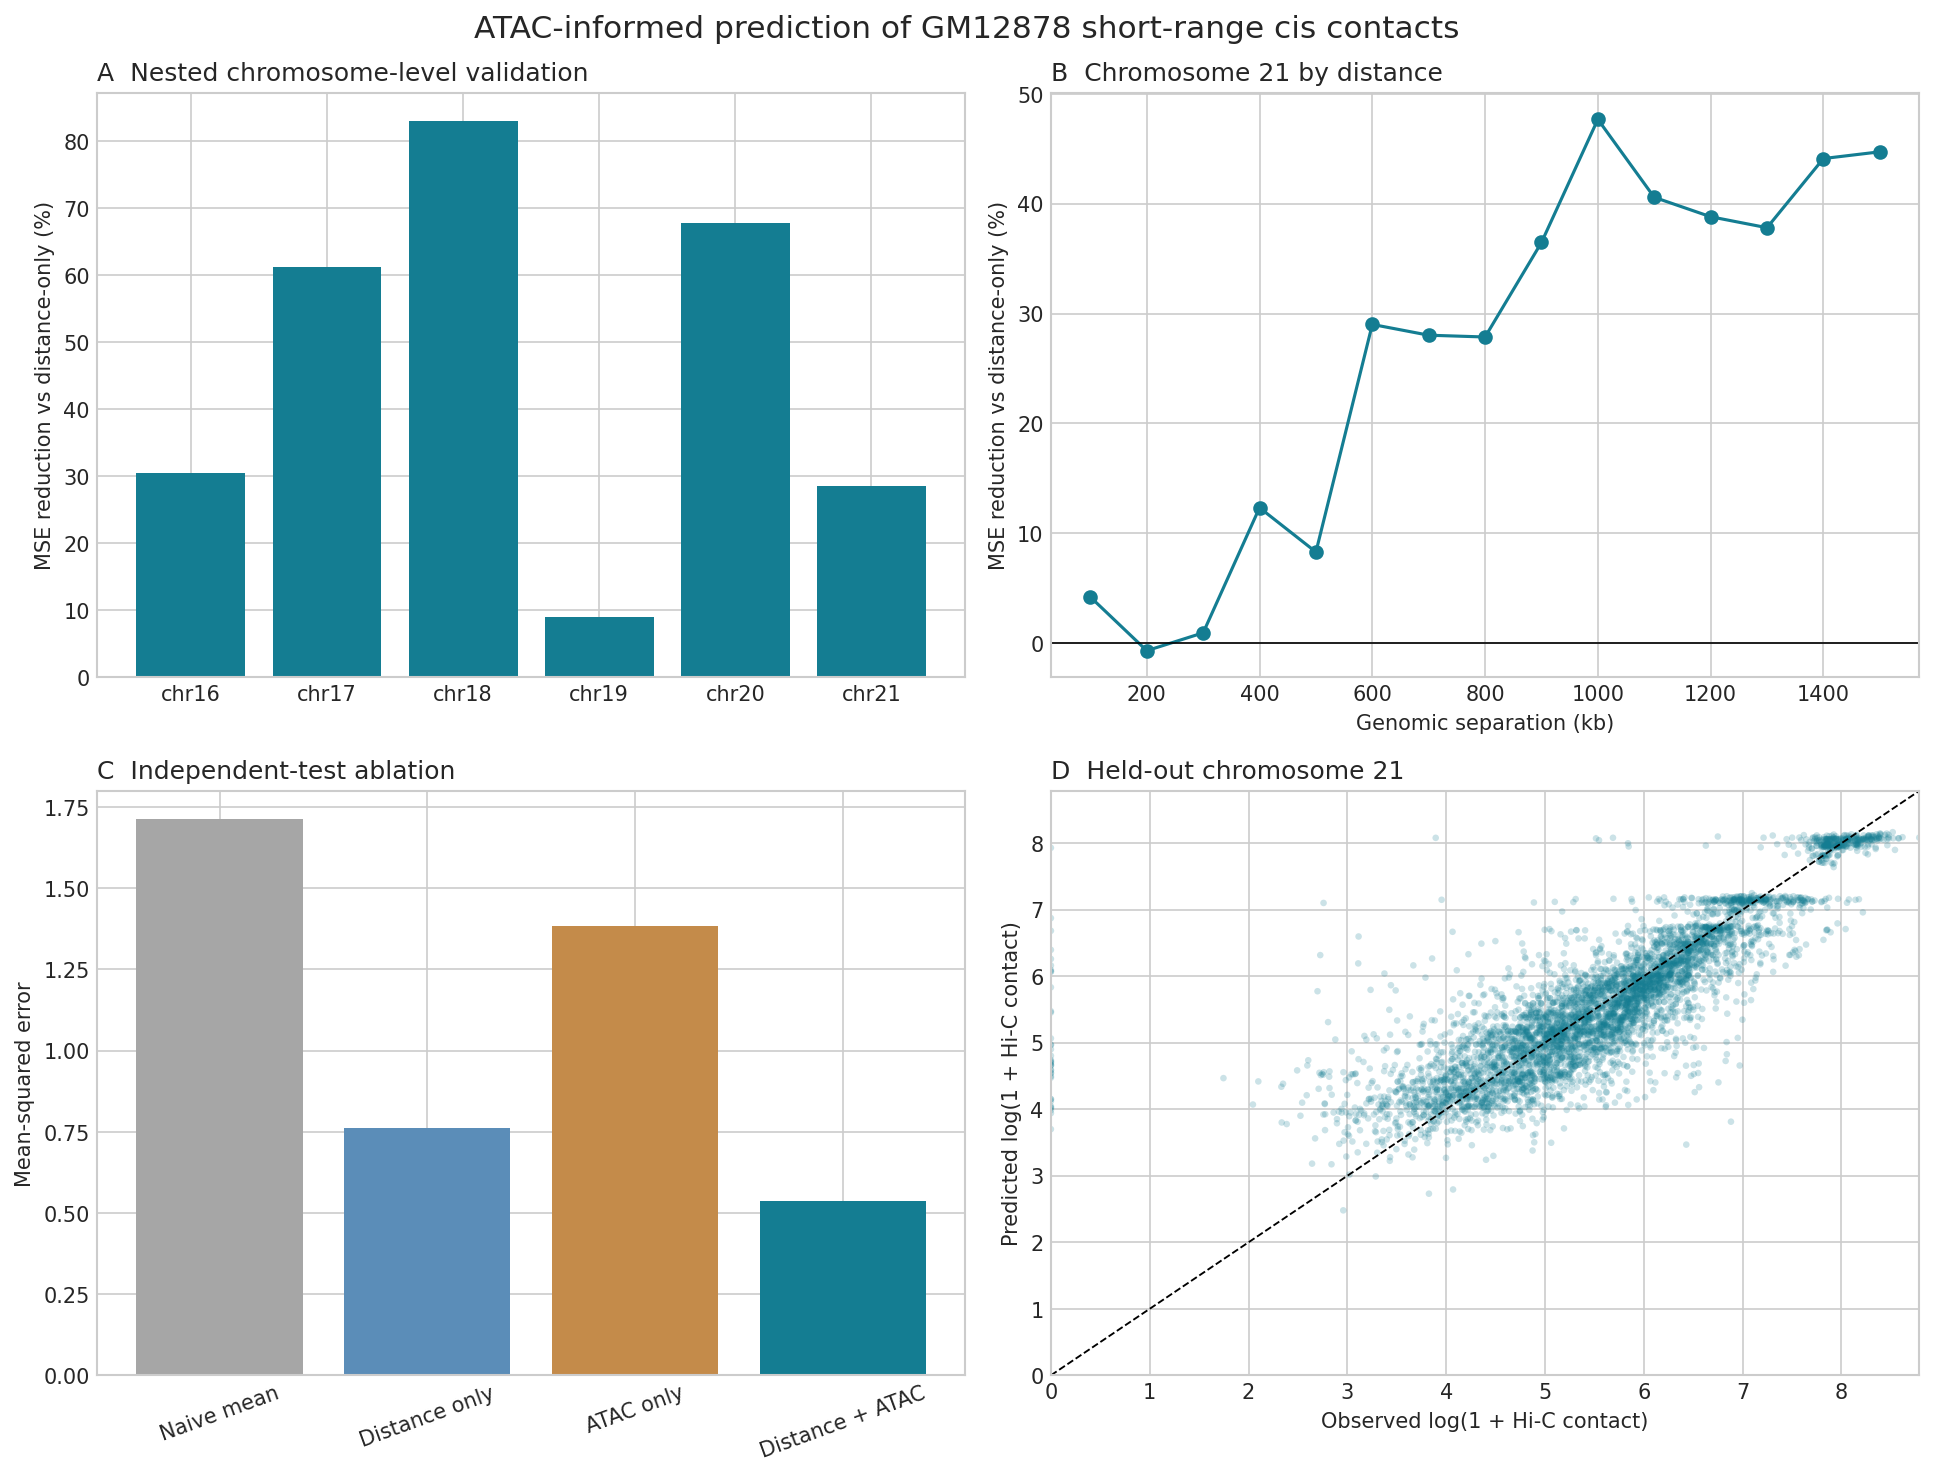

In [11]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# A: nested chromosome validation
axes[0, 0].bar(
    nested_results_table["test_chromosome"],
    nested_results_table["MSE_improvement_percent"],
    color="#147D92",
)
axes[0, 0].axhline(0, color="black", linewidth=0.8)
axes[0, 0].set_ylabel("MSE reduction vs distance-only (%)")
axes[0, 0].set_title("A  Nested chromosome-level validation", loc="left")

# B: distance-stratified performance
axes[0, 1].plot(
    distance_results_table["distance_kb"],
    distance_results_table["MSE_improvement_percent"],
    marker="o",
    color="#147D92",
)
axes[0, 1].axhline(0, color="black", linewidth=0.8)
axes[0, 1].set_xlabel("Genomic separation (kb)")
axes[0, 1].set_ylabel("MSE reduction vs distance-only (%)")
axes[0, 1].set_title("B  Chromosome 21 by distance", loc="left")

# C: ablation comparison
axes[1, 0].bar(
    ablation_results_table["model"],
    ablation_results_table["MSE"],
    color=["#A6A6A6", "#5B8DB8", "#C48B4A", "#147D92"],
)
axes[1, 0].set_ylabel("Mean-squared error")
axes[1, 0].set_title("C  Independent-test ablation", loc="left")
axes[1, 0].tick_params(axis="x", rotation=20)

# D: observed versus predicted
axes[1, 1].scatter(
    y_test,
    primary_prediction,
    s=10,
    alpha=0.22,
    color="#147D92",
    edgecolors="none",
)
plot_limit = max(float(y_test.max()), float(primary_prediction.max()))
axes[1, 1].plot(
    [0, plot_limit],
    [0, plot_limit],
    linestyle="--",
    color="black",
    linewidth=0.9,
)
axes[1, 1].set_xlim(0, plot_limit)
axes[1, 1].set_ylim(0, plot_limit)
axes[1, 1].set_xlabel("Observed log(1 + Hi-C contact)")
axes[1, 1].set_ylabel("Predicted log(1 + Hi-C contact)")
axes[1, 1].set_title("D  Held-out chromosome 21", loc="left")

fig.suptitle(
    "ATAC-informed prediction of GM12878 short-range cis contacts",
    fontsize=15,
)
fig.tight_layout()

figure_path = RESULTS_DIR / "ATAC_HiC_validated_summary.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

**Figure 1 | ATAC-informed prediction of short-range cis Hi-C contacts.**  
**A**, Percentage reduction in MSE relative to a chromosome-specific distance-only baseline during nested leave-one-chromosome-out validation. Hyperparameters were selected without access to the outer test chromosome. **B**, MSE reduction across genomic separations of 100 kb–1.5 Mb on the independent chromosome-21 test set. **C**, Independent-test comparison of a naive mean, distance-only, ATAC-only and combined model. **D**, Predicted versus observed log-transformed VC_SQRT-balanced contacts on chromosome 21. The dashed line denotes perfect calibration.

## 9. Export reproducible results

Every exported result has a unique name to prevent values from exploratory loops overwriting the primary test statistics.

In [12]:
primary_results_table.to_csv(
    RESULTS_DIR / "primary_chromosome21_results.csv", index=False
)
selection_table.to_csv(
    RESULTS_DIR / "primary_model_selection.csv", index=False
)
nested_results_table.to_csv(
    RESULTS_DIR / "nested_chromosome_validation.csv", index=False
)
ablation_results_table.to_csv(
    RESULTS_DIR / "chromosome21_model_ablation.csv", index=False
)
distance_results_table.to_csv(
    RESULTS_DIR / "chromosome21_distance_stratified.csv", index=False
)
joblib.dump(best_model, RESULTS_DIR / "GM12878_distance_ATAC_model.joblib")

validated_summary = {
    "project": "ATAC-informed prediction of short-range cis chromatin contacts",
    "cell_line": "GM12878",
    "hic_accession": "ENCFF916GWS",
    "atac_accession": "ENCFF667MDI",
    "genome_build": "hg38",
    "hic_normalisation": "VC_SQRT",
    "resolution_bp": RESOLUTION_BP,
    "maximum_separation_bp": MAXIMUM_SEPARATION_BP,
    "training_chromosomes": TRAINING_CHROMOSOMES,
    "validation_chromosome": VALIDATION_CHROMOSOME,
    "independent_test_region": "chr21 long arm",
    "selected_max_leaf_nodes": int(best_settings[0]),
    "selected_l2_regularisation": float(best_settings[1]),
    **{key: float(value) for key, value in primary_metrics.items()},
    "nested_chromosomes_improved": int(
        (nested_results_table["MSE_improvement_percent"] > 0).sum()
    ),
    "nested_median_MSE_improvement_percent": float(
        nested_results_table["MSE_improvement_percent"].median()
    ),
    "nested_median_MAE_improvement_percent": float(
        nested_results_table["MAE_improvement_percent"].median()
    ),
}

with open(RESULTS_DIR / "validated_results_summary.json", "w") as file:
    json.dump(validated_summary, file, indent=2)

print("Saved results to:", RESULTS_DIR)
print(json.dumps(validated_summary, indent=2))

Saved results to: /workspace/scratch/c48aa57ced8f/deliverables/validated_results
{
  "project": "ATAC-informed prediction of short-range cis chromatin contacts",
  "cell_line": "GM12878",
  "hic_accession": "ENCFF916GWS",
  "atac_accession": "ENCFF667MDI",
  "genome_build": "hg38",
  "hic_normalisation": "VC_SQRT",
  "resolution_bp": 100000,
  "maximum_separation_bp": 1500000,
  "training_chromosomes": [
    "chr16",
    "chr17",
    "chr18",
    "chr19"
  ],
  "validation_chromosome": "chr20",
  "independent_test_region": "chr21 long arm",
  "selected_max_leaf_nodes": 7,
  "selected_l2_regularisation": 0.1,
  "distance_baseline_MSE": 0.760244085766586,
  "distance_ATAC_MSE": 0.5354537584211401,
  "distance_baseline_MAE": 0.6351331571677535,
  "distance_ATAC_MAE": 0.4463199897999969,
  "Pearson": 0.8207268710510285,
  "Spearman": 0.8583626211122286,
  "R2": 0.6721986229455137,
  "MSE_improvement_percent": 29.568178372447367,
  "MAE_improvement_percent": 29.728123187542337,
  "nested_ch

## 10. Interpretation and limitations

### Interpretation

Genomic distance explains a substantial fraction of local contact variation, as expected from polymer behaviour and chromosome organisation. ATAC-derived features are weaker when used alone, but their addition to distance improves prediction on an independently held-out chromosome and across nested chromosome-level validation. The result therefore supports a reproducible predictive association between regional accessibility and local cis contact strength in GM12878.

### Limitations

1. **One cell line.** The analysis does not establish cross-cell-type generalisation.
2. **Restricted genomic scope.** Only chromosomes 16–21 and cis contacts up to 1.5 Mb are evaluated.
3. **Coarse resolution.** At 100 kb, individual regulatory elements and fine-scale loops cannot be resolved.
4. **Correlated observations.** Genomic bins participate in multiple pairs; pair counts should not be interpreted as independent biological replicates.
5. **Correlated features.** Several ATAC features are deterministic transformations of the same two anchor signals. The ablation supports their joint predictive value but not the unique biological importance of any single transformed feature.
6. **Observational design.** Predictive improvement does not establish that accessibility causes contact formation.
7. **No external cell-line validation.** Applying the fixed pipeline to a second matched ATAC/Hi-C dataset is the most valuable future extension.

### Scope of the claim

The defensible conclusion is:

> In GM12878, ATAC-derived anchor features improve prediction of VC_SQRT-balanced short-range cis Hi-C contact strength beyond genomic distance alone.

The analysis does **not** claim that ATAC-seq replaces Hi-C, predicts trans contacts, reconstructs whole contact maps or identifies causal chromatin interactions.